# Real-world Data Wrangling

In this project, you will apply the skills you acquired in the course to gather and wrangle real-world data with two datasets of your choice.

You will retrieve and extract the data, assess the data programmatically and visually, accross elements of data quality and structure, and implement a cleaning strategy for the data. You will then store the updated data into your selected database/data store, combine the data, and answer a research question with the datasets.

Throughout the process, you are expected to:

1. Explain your decisions towards methods used for gathering, assessing, cleaning, storing, and answering the research question
2. Write code comments so your code is more readable

## 1. Gather data

In this section, you will extract data using two different data gathering methods and combine the data. Use at least two different types of data-gathering methods.

### **1.1.** Problem Statement
In 2-4 sentences, explain the kind of problem you want to look at and the datasets you will be wrangling for this project.

I want to look into what type (manufacturer / model) of aircraft are more involved in fatal accidents than other ones. In addition, I would like to see if year manufacturered has something to do with aircraft fatal accidents. 

I will be using the FAA aircraft registry dataset and the NTSB accident database on Kaggle.

### **1.2.** Gather at least two datasets using two different data gathering methods

List of data gathering methods:

- Download data manually
- Programmatically downloading files
- Gather data by accessing APIs
- Gather and extract data from HTML files using BeautifulSoup
- Extract data from a SQL database

Each dataset must have at least two variables, and have greater than 500 data samples within each dataset.

For each dataset, briefly describe why you picked the dataset and the gathering method (2-3 full sentences), including the names and significance of the variables in the dataset. Show your work (e.g., if using an API to download the data, please include a snippet of your code). 

Load the dataset programmtically into this notebook.

In [2]:
import kagglehub
import os
import pandas as pd
import matplotlib.pyplot as plt

#### Dataset 1 - NTSB Fatal Avaiation Accidents

Type: CSV

Method: Kaggle Download

Dataset variables:

*   N
*   EventDate
*   State

In [16]:
path = kagglehub.dataset_download("sainin/fatal-aviation-accidents-jan2010-feb2025")
accident_data = pd.read_csv(os.path.join(path, "a8f0c8d2-d8a5-4420-91b0-9033d2064f6fAviationData.csv"))

# Remove any columns we don't need
accident_data = accident_data[["N", "EventDate", "State"]]

accident_data.head()

,N,EventDate,State
0,N321BA,2025-02-06T16:20:00Z,Alaska
1,PK-LUV,2025-02-06T03:20:00Z,NaN
2,HC-CQY,2025-02-01T14:00:00Z,NaN
3,XA-UCI,2025-01-31T19:07:00Z,Pennsylvania
4,"N709PS, UNREG",2025-01-29T21:48:00Z,District of Columbia


#### Dataset 2 - FAA Aircaft Registry

Type: CSV

Method: Download from FAA Website

Dataset variables:

*   N-Number
*   Year MFR
*   Kit MFR

In [17]:
registry_data = pd.read_csv("data-wrangling/aircraft-registry.csv")

# Remove any columns we don't need
registry_data = registry_data[["N-NUMBER", "YEAR MFR", "MFR MDL CODE"]]

registry_data.head()

,N-NUMBER,YEAR MFR,MFR MDL CODE
0,100,1940,7100510
1,10000,,2130004
2,10001,1928,9601202
3,10004,,2072738
4,10006,1955,1152020


#### Dataset 3

Type: CSV

Method: Download from FAA Website

Dataset variables:

*   Year MFR
*   Kit MFR

In [18]:
model_data = pd.read_csv("data-wrangling/aircraft-models.csv")

# Remove any columns we don't need
model_data = model_data[["CODE", "MFR", "MODEL"]]

#### Merged Aircraft Dataset

In [19]:
aircraft_data = registry_data.merge(model_data, left_on="MFR MDL CODE", right_on="CODE", how="left")

aircraft_data.head()

,N-NUMBER,YEAR MFR,MFR MDL CODE,CODE,MFR,MODEL
0,100,1940,7100510,7100510,PIPER,J3C-65
1,10000,,2130004,2130004,CIRRUS DESIGN CORP,SR22T
2,10001,1928,9601202,9601202,WACO,ASO
3,10004,,2072738,2072738,CESSNA,T182T
4,10006,1955,1152020,1152020,BEECH,D-45 (T-34B)


Optional data storing step: You may save your raw dataset files to the local data store before moving to the next step.

In [ ]:
#Optional: store the raw data in your local data store

## 2. Assess data

Assess the data according to data quality and tidiness metrics using the report below.

List **two** data quality issues and **two** tidiness issues. Assess each data issue visually **and** programmatically, then briefly describe the issue you find.  **Make sure you include justifications for the methods you use for the assessment.**

### Quality Issue 1:

In [20]:
accident_data.head()

accident_data[accident_data.duplicated(keep=False)]

,N,EventDate,State
72,D-ECHF,2024-09-07T14:40:00Z,NaN
73,D-ECHF,2024-09-07T14:40:00Z,NaN


Issue and justification: There are duplicate values that need to be removed, so they don't skew the results

### Quality Issue 2:

In [26]:
print(accident_data["State"].value_counts().sort_index())

invalid_states = ["Atlantic Ocean", "Caribbean Sea", "Gulf of Mexico"]

accident_data[accident_data["State"].isin(invalid_states)]

State
Alabama                  57
Alaska                  139
Arizona                 116
Arkansas                 65
Atlantic Ocean           10
California              359
Caribbean Sea             2
Colorado                109
Connecticut              18
Delaware                  5
District of Columbia      1
Florida                 253
Georgia                 126
Gulf of Mexico            4
Hawaii                   26
Idaho                    63
Illinois                 59
Indiana                  58
Iowa                     40
Kansas                   39
Kentucky                 29
Louisiana                67
Maine                    19
Maryland                 19
Massachusetts            29
Michigan                 73
Minnesota                52
Mississippi              36
Missouri                 57
Montana                  45
Nebraska                 40
Nevada                   55
New Hampshire            11
New Jersey               34
New Mexico               57
New York      

,N,EventDate,State
391,N13384,2023-08-04T21:17:00Z,Caribbean Sea
698,N6713A,2022-08-18T10:15:00Z,Atlantic Ocean
1180,N670BS,2021-02-24T12:04:00Z,Atlantic Ocean
1186,N13AT,2021-02-15T16:14:00Z,Caribbean Sea
1527,N79LP,2019-12-07T10:18:00Z,Gulf of Mexico
1577,N778PA,2019-10-16T23:33:00Z,Gulf of Mexico
1754,N832R,2019-05-24T17:55:00Z,Atlantic Ocean
1865,N3016L,2019-02-01T14:15:00Z,Atlantic Ocean
1948,N555PM,2018-10-25T11:19:00Z,Atlantic Ocean
2186,N4ZQ,2018-03-31T11:17:00Z,Atlantic Ocean


Issue and justification: There are values in the state columns that are bodies of water and not states.

### Quality Issue 3:

In [32]:
aircraft_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309586 entries, 0 to 309585
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   N-NUMBER      309586 non-null  object
 1   YEAR MFR      309586 non-null  object
 2   MFR MDL CODE  309586 non-null  object
 3   CODE          309586 non-null  object
 4   MFR           309586 non-null  object
 5   MODEL         309586 non-null  object
dtypes: object(6)
memory usage: 14.2+ MB


In [35]:
aircraft_data["YEAR MFR"].value_counts()

YEAR MFR
        64080
1946     8605
1978     6854
1979     6457
1977     6423
        ...  
1923        1
1909        1
1913        1
1912        1
1911        1
Name: count, Length: 117, dtype: int64

<Axes: xlabel='YEAR MFR'>

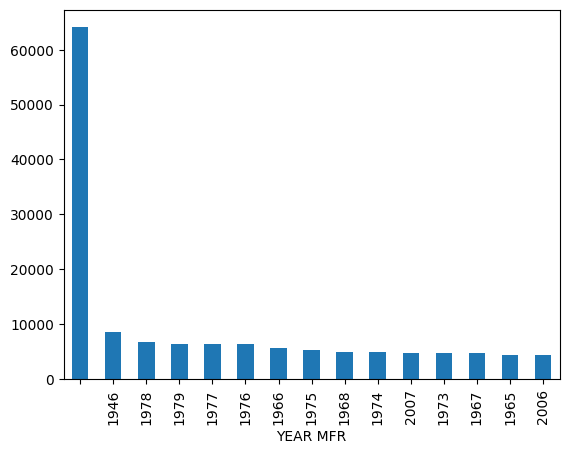

In [36]:
# Quanlity Issue 3 - empty year manufactured values
aircraft_data["YEAR MFR"].value_counts().head(15).plot(kind="bar")

In [ ]:
aircraft_data = aircraft_data.apply(lambda col: col.str.strip() if col.dtype == "object" else col)

In [ ]:
empty_counts = (aircraft_data == "").sum()
empty_counts[empty_counts > 0]

print(empty_counts)

N-NUMBER            0
YEAR MFR        64080
MFR MDL CODE        0
CODE                0
MFR                 0
MODEL               0
dtype: int64


In [37]:
aircraft_data.head()

,N-NUMBER,YEAR MFR,MFR MDL CODE,CODE,MFR,MODEL
0,100,1940,7100510,7100510,PIPER,J3C-65
1,10000,,2130004,2130004,CIRRUS DESIGN CORP,SR22T
2,10001,1928,9601202,9601202,WACO,ASO
3,10004,,2072738,2072738,CESSNA,T182T
4,10006,1955,1152020,1152020,BEECH,D-45 (T-34B)


Issue and justification: There are spaces around the year manufacturer, so it makes it so we can't do analysis based on the year.

### Tidiness Issue 1:

In [31]:
accident_data[accident_data["N"].str.contains(",", na=False)]

,N,EventDate,State
4,"N709PS, UNREG",2025-01-29T21:48:00Z,District of Columbia
63,"N313YK, N5287",2024-09-22T12:48:00Z,California
65,"N78074, N844CP",2024-09-16T09:46:00Z,Nevada
119,"VH-HQH, VH-HYQ",2024-07-25T06:10:00Z,NaN
137,"N6177J, N795LA",2024-07-11T14:07:00Z,Louisiana
...,...,...,...
4891,"G-JAST, G-MARX",2010-09-04T16:00:00Z,NaN
4934,"N7470C, N8829A",2010-08-04T18:20:00Z,Texas
5080,"N823AG, N788LL",2010-03-20T11:45:00Z,Florida
5121,"N8718L, N825BC, N2472W",2010-02-06T14:27:00Z,Colorado


Issue and justification: In the case where there are multiple aircraft involved in an accident there are multiple tail numbers in the "N" column. In order count the accidents by type of aircraft I need to separate these into separate rows.

### Tidiness Issue 2: 

In [37]:
accident_data["EventDate"].head(10)    

0    2025-02-06T16:20:00Z
1    2025-02-06T03:20:00Z
2    2025-02-01T14:00:00Z
3    2025-01-31T19:07:00Z
4    2025-01-29T21:48:00Z
5    2025-01-29T05:00:00Z
6    2025-01-25T13:35:00Z
7    2025-01-14T07:22:00Z
8    2025-01-13T01:30:00Z
9    2025-01-12T15:30:00Z
Name: EventDate, dtype: object

Issue and justification: The date and time are in the same column and should be separated.

## 3. Clean data
Clean the data to solve the 4 issues corresponding to data quality and tidiness found in the assessing step. **Make sure you include justifications for your cleaning decisions.**

After the cleaning for each issue, please use **either** the visually or programatical method to validate the cleaning was succesful.

At this stage, you are also expected to remove variables that are unnecessary for your analysis and combine your datasets. Depending on your datasets, you may choose to perform variable combination and elimination before or after the cleaning stage. Your dataset must have **at least** 4 variables after combining the data.

In [43]:
# FILL IN - Make copies of the datasets to ensure the raw dataframes 
# are not impacted
cleaned_accident_data = accident_data.copy()

### **Quality Issue 1: FILL IN**

In [52]:
# FILL IN - Apply the cleaning strategy
cleaned_accident_data = cleaned_accident_data.drop_duplicates()

In [53]:
# FILL IN - Validate the cleaning was successful
cleaned_accident_data[cleaned_accident_data.duplicated(keep=False)]

,N,EventDate,State


Justification: Duplicates will skew the data if not removed.

### **Quality Issue 2: FILL IN**

In [54]:
cleaned_accident_data = cleaned_accident_data[~cleaned_accident_data["State"].isin(invalid_states)]

In [55]:
cleaned_accident_data[cleaned_accident_data["State"].isin(invalid_states)]

,N,EventDate,State


Justification: I removed the rows for bodies of water so we can focus on state data.

### **Tidiness Issue 1: FILL IN**

In [56]:
# Each aircraft gets its own row
cleaned_accident_data = cleaned_accident_data.assign(
    N=cleaned_accident_data["N"].str.split(",")
).explode("N")

# Clean up whitespace
cleaned_accident_data["N"] = cleaned_accident_data["N"].str.strip()

In [57]:
cleaned_accident_data[cleaned_accident_data["N"].str.contains(",", na=False)]

,N,EventDate,State


Justification: There are cases when multiple aircraft are involed in an accident, but we need each aircraft to have it's own row so we can analyze different aircraft.

### **Tidiness Issue 2: FILL IN**

In [58]:
cleaned_accident_data["EventDate"] = pd.to_datetime(cleaned_accident_data["EventDate"]).dt.date                                                                                                                                                                                                                           

In [59]:
cleaned_accident_data["EventDate"].head(10)    

0    2025-02-06
1    2025-02-06
2    2025-02-01
3    2025-01-31
4    2025-01-29
4    2025-01-29
5    2025-01-29
6    2025-01-25
7    2025-01-14
8    2025-01-13
Name: EventDate, dtype: object

Justification: We only need the date so we can replace the EventDate with just the date value and not worry about the time.

### **Remove unnecessary variables and combine datasets**

Depending on the datasets, you can also peform the combination before the cleaning steps.

In [ ]:
#FILL IN - Remove unnecessary variables and combine datasets

## 4. Update your data store
Update your local database/data store with the cleaned data, following best practices for storing your cleaned data:

- Must maintain different instances / versions of data (raw and cleaned data)
- Must name the dataset files informatively
- Ensure both the raw and cleaned data is saved to your database/data store

In [ ]:
#FILL IN - saving data

## 5. Answer the research question

### **5.1:** Define and answer the research question 
Going back to the problem statement in step 1, use the cleaned data to answer the question you raised. Produce **at least** two visualizations using the cleaned data and explain how they help you answer the question.

*Research question:* FILL IN from answer to Step 1

In [ ]:
#Visual 1 - FILL IN

*Answer to research question:* FILL IN

In [ ]:
#Visual 2 - FILL IN

*Answer to research question:* FILL IN

### **5.2:** Reflection
In 2-4 sentences, if you had more time to complete the project, what actions would you take? For example, which data quality and structural issues would you look into further, and what research questions would you further explore?

*Answer:* FILL IN